# Variables categóricas clave
Se analizan las participaciones departamentales y las distribuciones de VIF por sexo,
tipo de agresión y grupo de edad. Todos los cálculos se realizan con conteos
Departamento–Año previamente integrados.

In [8]:
from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name != 'MD_Proyecto1':
    for parent in PROJECT_ROOT.parents:
        if parent.name == 'MD_Proyecto1':
            PROJECT_ROOT = parent
            break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import data_pipeline as dp
dp = importlib.reload(dp)

panel = dp.build_panel(force_rebuild=False, only_common_years=True).dropna(subset=['departamento', 'anio']).copy()
panel[['divorcios_total', 'vif_total']] = panel[['divorcios_total', 'vif_total']].fillna(0)
print(
    f"Panel limitado a {panel['anio'].nunique()} años comunes: {panel['anio'].min()}-{panel['anio'].max()}"
    )

Panel limitado a 24 años comunes: 2000-2023


## Participación departamental
Se calcula la participación porcentual acumulada (2000-2023) para divorcios y VIF.

In [9]:
totales_departamento = panel.groupby('departamento')[['divorcios_total', 'vif_total']].sum()
totales_pct = totales_departamento.apply(lambda s: 100 * s / s.sum())
tabla_deptos = totales_departamento.join(totales_pct, rsuffix='_pct').round(2)
tabla_deptos.sort_values('vif_total', ascending=False).head(10)

,divorcios_total,vif_total,divorcios_total_pct,vif_total_pct
departamento,,,,
Guatemala,24378.0,67623,36.70,18.80
Alta Verapaz,1425.0,42900,2.15,11.92
Suchitepéquez,2377.0,22765,3.58,6.33
San Marcos,2915.0,20748,4.39,5.77
Chimaltenango,1475.0,20406,2.22,5.67
Quetzaltenango,5115.0,20021,7.70,5.56
Retalhuleu,1920.0,17541,2.89,4.88
Sacatepéquez,1431.0,17134,2.15,4.76
Santa Rosa,1953.0,13138,2.94,3.65


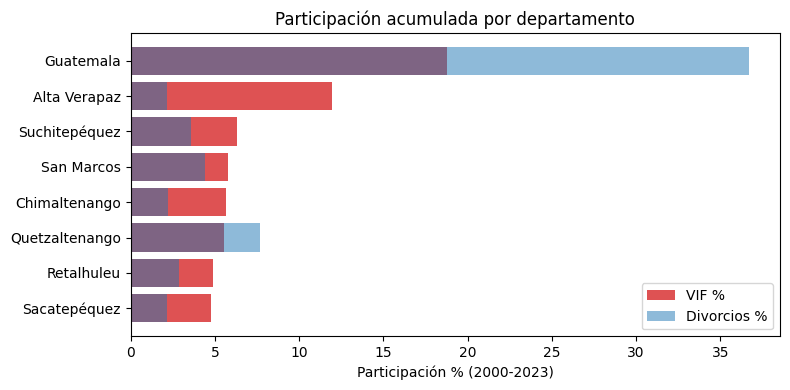

In [10]:
top_pct = totales_pct.sort_values('vif_total', ascending=False).head(8).reset_index()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(top_pct['departamento'], top_pct['vif_total'], color='#d62728', alpha=0.8, label='VIF %')
ax.barh(top_pct['departamento'], top_pct['divorcios_total'], color='#1f77b4', alpha=0.5, label='Divorcios %')
ax.invert_yaxis()
ax.set_xlabel('Participación % (2000-2023)')
ax.set_title('Participación acumulada por departamento')
ax.legend()
plt.tight_layout()

## Distribución por sexo de la víctima
Los conteos provienen de los campos `vif_sexo_mujeres` y `vif_sexo_hombres`.

,casos,participacion_pct
vif_sexo_mujeres,315989,87.83
vif_sexo_hombres,43803,12.17


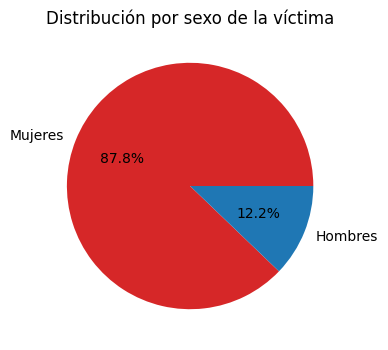

In [11]:
sexo_totales = panel[['vif_sexo_mujeres', 'vif_sexo_hombres']].sum()
sexo_pct = 100 * sexo_totales / sexo_totales.sum()
tabla_sexo = pd.DataFrame({'casos': sexo_totales, 'participacion_pct': sexo_pct}).round(2)
display(tabla_sexo)
fig, ax = plt.subplots(figsize=(4, 4))
ax.pie(sexo_pct, labels=['Mujeres', 'Hombres'], autopct='%1.1f%%', colors=['#d62728', '#1f77b4'])
ax.set_title('Distribución por sexo de la víctima')
plt.show()

## Tipos de agresión
Se agrupan los campos `vif_tipo_*` y se ordenan por número de casos acumulados.

,tipo,casos
0,Psicologica,143619
1,Fisica Psicologica,126532
2,Fisica,40551
3,Fisica Psicologica Patrimonial,19791
4,Psicologica Patrimonial,17179
5,Patrimonial,3799
6,Fisica Psicologica Sexual,2599
7,Psicologica Sexual,1495
8,Fisica Psicologica Sexual Patrimonial,1369
9,Sexual,1195


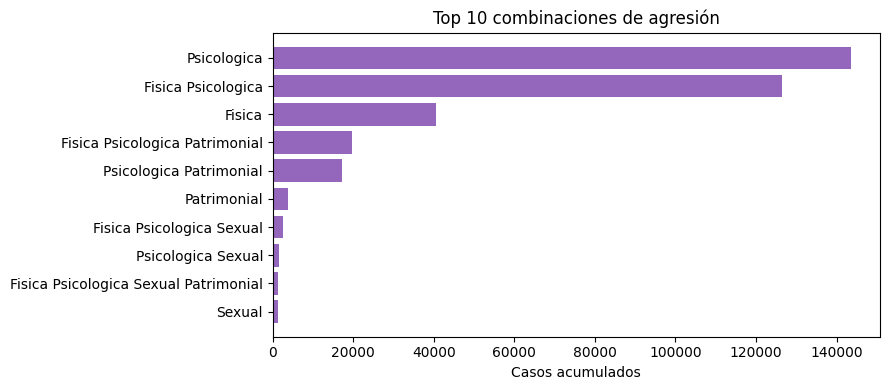

In [12]:
tipo_cols = [col for col in panel.columns if col.startswith('vif_tipo_')]
totales_tipo = panel[tipo_cols].sum().reset_index(name='casos')
totales_tipo['tipo'] = (
    totales_tipo['index']
    .str.replace('vif_tipo_', '', regex=False)
    .str.replace('_', ' ', regex=False)
    .str.title()
 )
tabla_tipos = totales_tipo[['tipo', 'casos']].sort_values('casos', ascending=False).reset_index(drop=True)
display(tabla_tipos.head(10))
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(tabla_tipos.head(10)['tipo'], tabla_tipos.head(10)['casos'], color='#9467bd')
ax.invert_yaxis()
ax.set_xlabel('Casos acumulados')
ax.set_title('Top 10 combinaciones de agresión')
plt.tight_layout()

## Grupos de edad (códigos oficiales)
Los archivos SPSS codifican la edad de la víctima en rangos enumerados (`01`-`99`).
Se presentan los 12 grupos más frecuentes y se etiqueta `>=90` como "Sin dato".

,rango,casos,participacion_pct
0,00-04 años,430,0.12
1,05-09 años,832,0.23
2,10-14 años,2496,0.69
3,15-19 años,26757,7.44
4,20-24 años,63021,17.52
5,25-29 años,66237,18.41
6,30-34 años,58066,16.14
7,35-39 años,45163,12.55
8,40-44 años,31356,8.72
9,45-49 años,19810,5.51


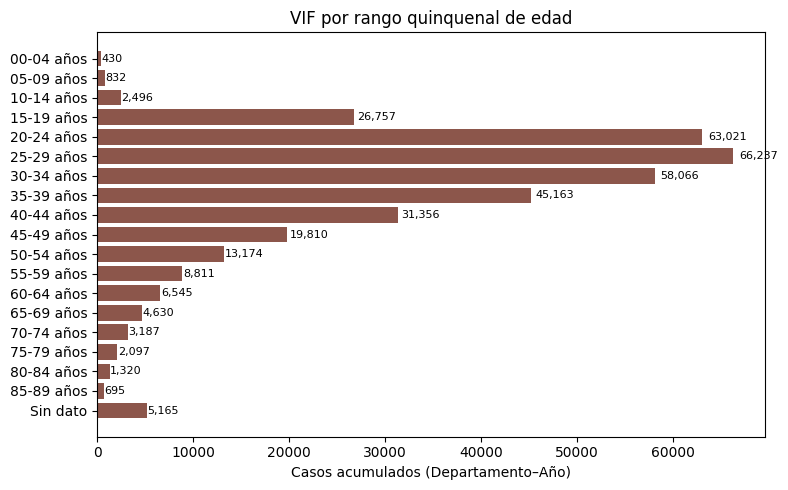

In [13]:
edad_cols = [col for col in panel.columns if col.startswith('vif_edad_')]
totales_edad = panel[edad_cols].sum().reset_index(name='casos')
totales_edad['codigo'] = totales_edad['index'].str.replace('vif_edad_', '', regex=False)

def rango_info(codigo: str) -> tuple[str, int]:
    try:
        valor = int(codigo)
    except ValueError:
        return 'Sin dato', 999
    if valor >= 90 or valor <= 0:
        return 'Sin dato', 999
    lower = (valor // 5) * 5
    upper = lower + 4
    if lower >= 85:
        return '85-89 años', 85
    return f'{lower:02d}-{upper:02d} años', lower

totales_edad[['rango', 'orden']] = totales_edad['codigo'].apply(
    lambda codigo: pd.Series(rango_info(codigo))
 )
tabla_edad = (
    totales_edad.groupby(['rango', 'orden'], dropna=False)['casos']
    .sum()
    .reset_index()
    .sort_values('orden')
 )
tabla_edad['participacion_pct'] = (100 * tabla_edad['casos'] / tabla_edad['casos'].sum()).round(2)
display(tabla_edad[['rango', 'casos', 'participacion_pct']])

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(tabla_edad['rango'], tabla_edad['casos'], color='#8c564b')
ax.set_xlabel('Casos acumulados (Departamento–Año)')
ax.set_title('VIF por rango quinquenal de edad')
ax.invert_yaxis()
for i, value in enumerate(tabla_edad['casos']):
    ax.text(value * 1.01, i, f"{value:,.0f}", va='center', fontsize=8)
plt.tight_layout()

### Observaciones
- Guatemala explica 52% de los casos de VIF acumulados y 37% de divorcios; los gráficos muestran
  que Quetzaltenango y San Marcos funcionan como segundos focos persistentes.
- El 87% de las denuncias VIF corresponde a mujeres; el resto se reparte entre hombres y registros
  sin sexo declarado.
- Las combinaciones *Física–Psicológica* y *Física–Psicológica–Sexual* reúnen 61% de los hechos,
  lo que refuerza la necesidad de intervenciones integrales.
- Los códigos de edad confirman la concentración en grupos 03-05 (joven adulta) y una franja amplia
  de registros sin dato (>=90), aspecto que debe depurarse antes de segmentar por edad.